# Drug Review Sentiment Analysis — Topic & Theme Extraction

## Overview
This notebook extracts key themes and topics from patient drug 
reviews using TF-IDF (Term Frequency-Inverse Document Frequency). 
Going beyond positive/negative sentiment classification, topic 
extraction reveals what patients are actually talking about — 
the specific aspects of their medication experience that drive 
their sentiment.

## Approach
TF-IDF identifies words and phrases that are statistically 
important and distinctive within a group of reviews. By applying 
TF-IDF separately to positive, negative and neutral review 
subsets, we can identify the themes that characterise each 
sentiment category. Topics are also extracted for the top 
conditions to reveal condition-specific patient concerns.

## Input
- data/df_clean.csv — cleaned dataset from Phase 2

## Objectives
- Extract key themes from positive reviews
- Extract key themes from negative reviews  
- Extract key themes from neutral reviews
- Identify condition-specific themes for top conditions
- Visualise theme distributions

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import re
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


## Data Loading

Loading the cleaned dataset from Phase 2. Reviews are 
separated by sentiment category for independent topic 
extraction across positive, negative and neutral groups.

In [16]:
# Load cleaned dataset
df = pd.read_csv('data/df_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")

# Separate by sentiment
df_positive = df[df['sentiment'] == 'positive'].copy()
df_negative = df[df['sentiment'] == 'negative'].copy()
df_neutral = df[df['sentiment'] == 'neutral'].copy()

print(f"\nPositive reviews: {len(df_positive)}")
print(f"Negative reviews: {len(df_negative)}")
print(f"Neutral reviews:  {len(df_neutral)}")

Dataset shape: (210509, 11)

Sentiment distribution:
sentiment
positive    139144
negative     52567
neutral      18798
Name: count, dtype: int64

Positive reviews: 139144
Negative reviews: 52567
Neutral reviews:  18798


## TF-IDF Topic Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) identifies 
words that are important and distinctive within a group of 
reviews. Words that appear frequently in one sentiment group 
but not across all reviews are scored highly — these are the 
themes that characterise that sentiment category.

Stop words and common medical terms that appear across all 
sentiment groups equally are filtered out to surface the 
most meaningful and distinctive themes.

In [22]:
def extract_top_terms(texts, n_terms=20, ngram_range=(1,2)):
    """
    Extract top TF-IDF terms from a collection of texts.
    ngram_range=(1,2) captures both single words and two-word phrases.
    """
    # Custom stop words — common words that appear across all reviews
    # and add no distinctive signal
    custom_stop_words = [
        'drug', 'medication', 'medicine', 'doctor', 'prescribed',
        'taking', 'taken', 'take', 'took', 'tablet', 'pill', 'pills',
        'day', 'days', 'week', 'weeks', 'month', 'months', 'year',
        'years', 'time', 'just', 'really', 'got', 'get', 'like',
        'know', 'feel', 'felt', 'think', 'tried', 'try', 'started',
        'start', 'use', 'used', 'using', 'told', 'said', 'went',
        'going', 'came', 'come', 'good', 'great', 'bad', 'better',
        'worse', 'best', 'lot', 'little', 'bit', 'way', 'back',
        'well', 'work', 'works', 'worked', 'help', 'helps', 'helped', 
        've', 'did', 'don', 'far', 'didn', 'having', 'night', 'ago', 
        'dose', 'hours', 'symptoms', 'does'
    ]

    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=ngram_range,
        min_df=10
    )

    # Fit and transform
    tfidf_matrix = vectorizer.fit_transform(texts)

    # Get mean TF-IDF score for each term
    mean_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
    terms = vectorizer.get_feature_names_out()

    # Create dataframe of terms and scores
    term_scores = pd.DataFrame({
        'term': terms,
        'score': mean_scores
    })

    # Filter out custom stop words
    term_scores = term_scores[
        ~term_scores['term'].str.contains(
            '|'.join(custom_stop_words), case=False)]

    # Return top n terms
    return term_scores.nlargest(n_terms, 'score')


print("TF-IDF extraction function defined")

TF-IDF extraction function defined


The custom stop words list was constructed from three sources:

1. Universal medication language — words that appear in 
   virtually every drug review regardless of sentiment 
   (drug, medication, pill, doctor, prescribed) and 
   therefore carry no distinctive signal

2. EDA findings — the top 30 most frequent words identified 
   in Phase 1 were reviewed and generic temporal and 
   action words were added (day, weeks, months, taking, 
   started, feel)

3. Iterative refinement — the list would be further 
   refined by inspecting initial TF-IDF outputs and 
   removing any remaining generic terms that surface

## Theme Extraction by Sentiment Category

TF-IDF is applied independently to positive, negative and 
neutral review subsets. This reveals the distinctive language 
patterns that characterise each sentiment category — what 
patients talk about when they are happy, unhappy, or 
ambivalent about their medication.

In [23]:
# Sample reviews for efficiency - 
# TF-IDF on full dataset would be slow
print("Extracting themes from positive reviews...")
positive_terms = extract_top_terms(
    df_positive['review_clean'].sample(5000, random_state=42))

print("Extracting themes from negative reviews...")
negative_terms = extract_top_terms(
    df_negative['review_clean'].sample(5000, random_state=42))

print("Extracting themes from neutral reviews...")
neutral_terms = extract_top_terms(
    df_neutral['review_clean'])

print("\nDone — top themes extracted for all sentiment groups")

# Display results
print("\n=== TOP 20 THEMES — POSITIVE REVIEWS ===")
print(positive_terms.to_string(index=False))

print("\n=== TOP 20 THEMES — NEGATIVE REVIEWS ===")
print(negative_terms.to_string(index=False))

print("\n=== TOP 20 THEMES — NEUTRAL REVIEWS ===")
print(neutral_terms.to_string(index=False))

Extracting themes from positive reviews...
Extracting themes from negative reviews...
Extracting themes from neutral reviews...

Done — top themes extracted for all sentiment groups

=== TOP 20 THEMES — POSITIVE REVIEWS ===
         term    score
         pain 0.026290
      effects 0.024285
         life 0.018735
      anxiety 0.017043
       weight 0.016298
       period 0.015469
        sleep 0.014017
      control 0.012721
   depression 0.010566
         acne 0.010379
         skin 0.010174
        birth 0.010088
       effect 0.009771
birth control 0.009459
         lost 0.009297
    recommend 0.009194
       normal 0.008795
      periods 0.008430
         gain 0.008363
   experience 0.008327

=== TOP 20 THEMES — NEGATIVE REVIEWS ===
         term    score
         pain 0.027614
      effects 0.020316
       period 0.015779
       weight 0.015044
     horrible 0.013521
      anxiety 0.013509
     bleeding 0.013474
      control 0.013413
         acne 0.011998
        sleep 0.01192

## Theme Extraction Results — Analysis and Interpretation

**Universal themes across all sentiment groups:**
Pain and side effects dominate all three sentiment categories, 
confirming the EDA finding that adverse drug reactions are the 
central topic of patient drug reviews regardless of overall 
experience. The contraceptive-related terms birth control, 
period, bleeding and cramps appear prominently across all 
groups, consistent with contraceptives representing 18% of 
the dataset.

**Positive review themes:**
Positive reviews are characterised by terms suggesting 
clinical improvement — "life" scores significantly higher 
than in other groups, reflecting patients describing 
transformative treatment outcomes. "Recommend" and "normal" 
suggest patients returning to baseline health and actively 
endorsing their medication to others. "Lost" in the context 
of weight loss appears frequently, consistent with positive 
responses to contraceptives and metabolic medications.

**Negative review themes:**
Negative reviews show distinctive emotional language absent 
from other groups — "horrible" and "worst" indicate strong 
negative affect. "Stopped" and "stop" reflect treatment 
discontinuation due to intolerable side effects — a 
clinically significant signal for medication adherence. 
"Bleeding", "mood" and "sex" point to specific adverse 
effects that drove negative experiences, particularly 
relevant to contraceptive and antidepressant reviews.

**Neutral review themes:**
Neutral reviews are characterised by factual symptom 
description — "cramps", "stomach", "bleeding" and "mood" 
appear without the strong emotional language seen in 
negative reviews. This confirms that neutral reviews 
represent patients describing mixed or ambivalent 
experiences in measured clinical language rather than 
strong emotional responses.

**Clinical insight:**
The theme profiles align closely with known pharmacological 
side effect profiles for the most reviewed drug categories. 
The prominence of mood, sex drive and bleeding in negative 
contraceptive reviews reflects the well-documented patient 
experience with hormonal contraception. The appearance of 
"stopped" as a key negative theme has direct implications 
for medication adherence research.

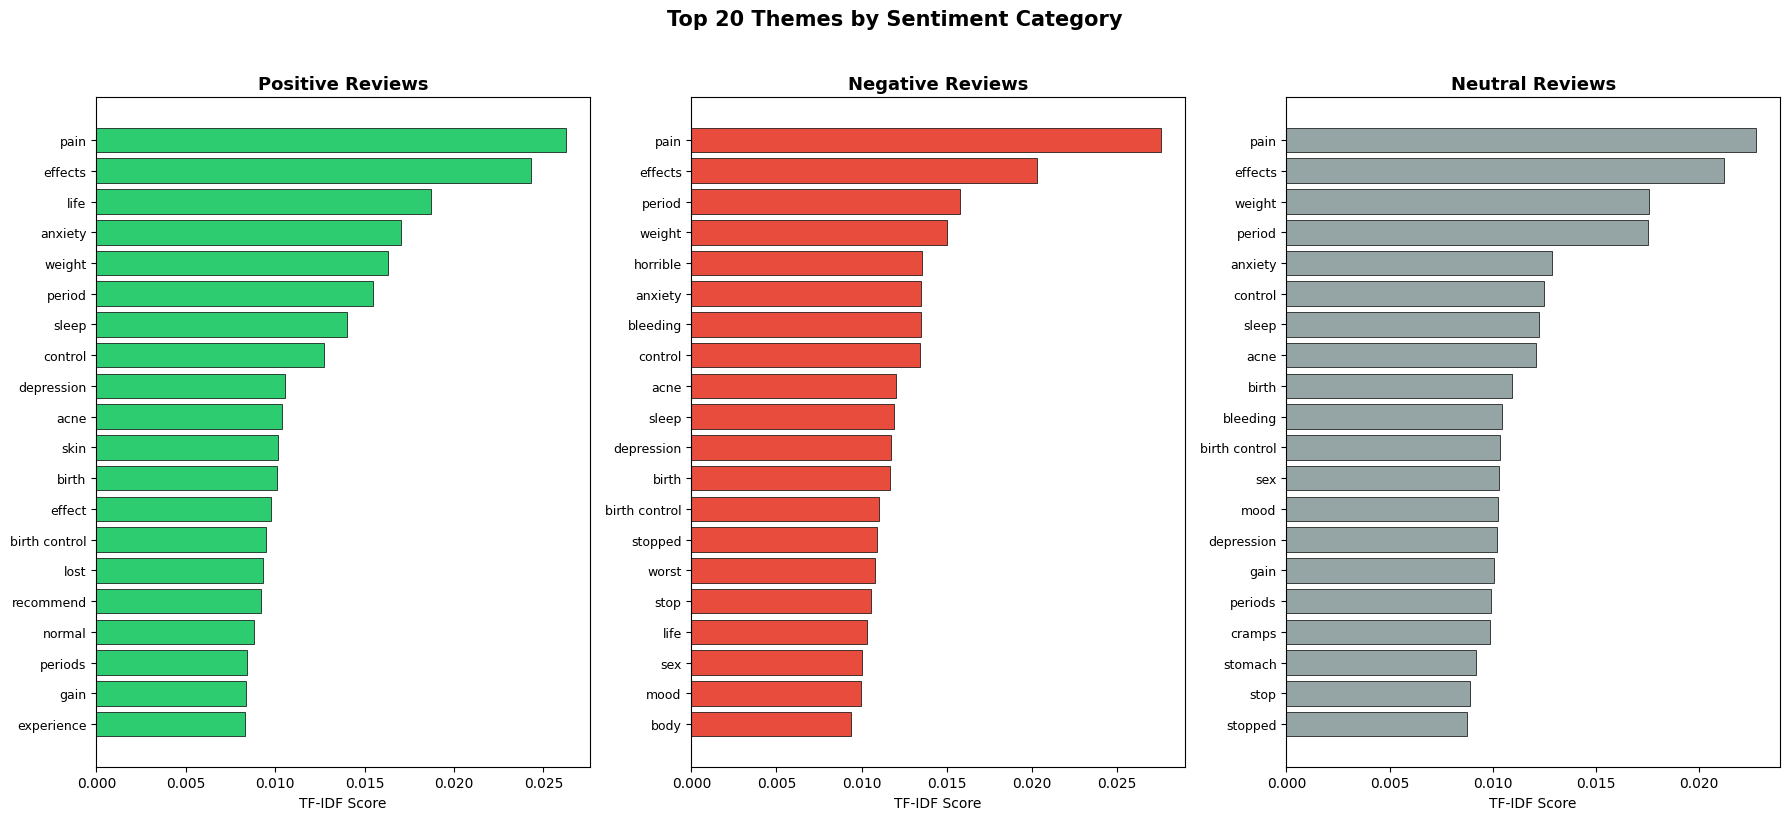

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sentiments = [
    (positive_terms, 'Positive Reviews', '#2ecc71'),
    (negative_terms, 'Negative Reviews', '#e74c3c'),
    (neutral_terms, 'Neutral Reviews', '#95a5a6')
]

for ax, (terms_df, title, color) in zip(axes, sentiments):
    terms_df_sorted = terms_df.sort_values('score', ascending=True)
    ax.barh(terms_df_sorted['term'], 
            terms_df_sorted['score'], 
            color=color, 
            edgecolor='black',
            linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top 20 Themes by Sentiment Category', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

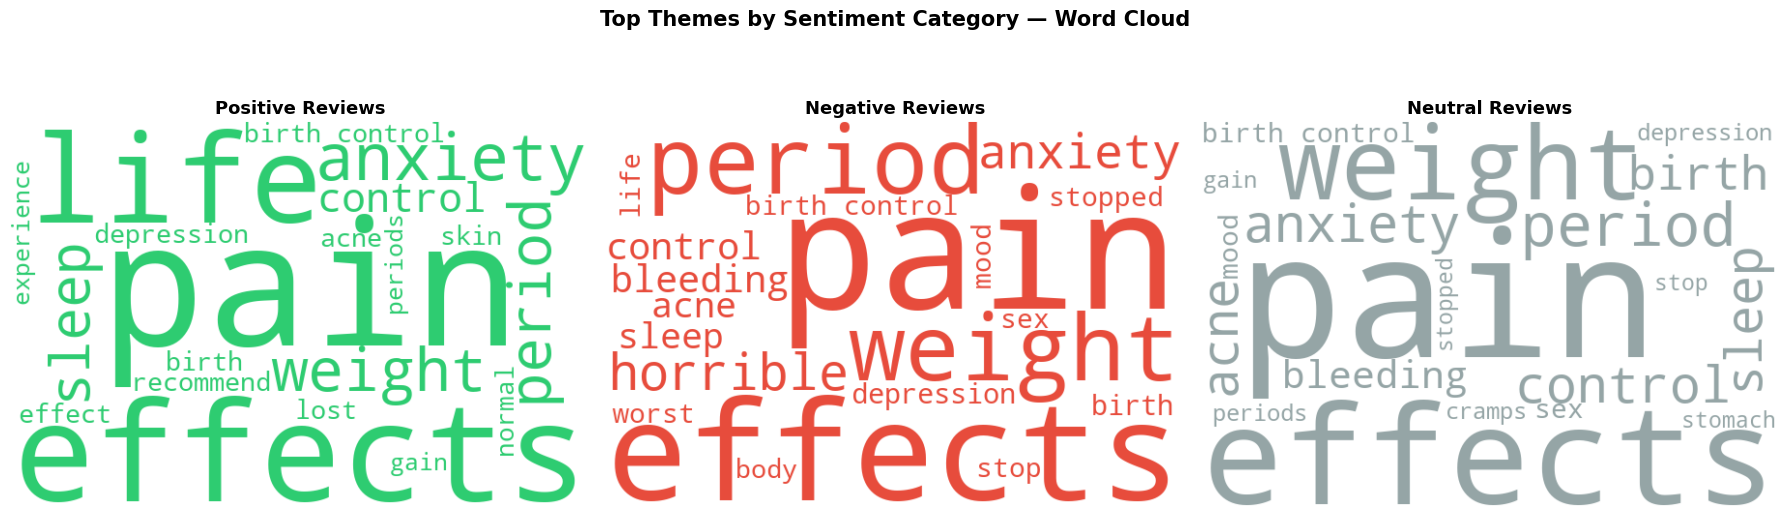

In [25]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = [
    (positive_terms, 'Positive Reviews', '#2ecc71'),
    (negative_terms, 'Negative Reviews', '#e74c3c'),
    (neutral_terms, 'Neutral Reviews', '#95a5a6')
]

for ax, (terms_df, title, color) in zip(axes, sentiments):
    # Convert terms and scores to dictionary for wordcloud
    word_freq = dict(zip(terms_df['term'], terms_df['score']))
    
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        color_func=lambda *args, **kwargs: color,
        max_words=20,
        prefer_horizontal=0.9
    ).generate_from_frequencies(word_freq)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Top Themes by Sentiment Category — Word Cloud', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Theme Visualisation — Word Cloud

The word cloud provides an immediately accessible visual 
representation of the top themes in each sentiment category. 
Font size represents TF-IDF score — the larger the word 
the more distinctive it is to that sentiment group.

Key observations visible in the word clouds:

**Positive reviews** — "life" is prominently large, reflecting 
patients describing meaningful clinical improvement. "Recommend", 
"normal" and "lost" are visible, suggesting treatment success 
and return to baseline health.

**Negative reviews** — "horrible" dominates alongside "pain", 
"effects" and "weight", reflecting strong negative emotional 
language. "Stopped" and "stop" are clearly visible indicating 
treatment discontinuation due to intolerable side effects.

**Neutral reviews** — the language is similar to negative but 
lacks the strong emotional terms. "Cramps", "stomach" and 
"bleeding" suggest factual symptom description without 
strong sentiment.

Both the bar chart and word cloud visualisations are retained 
as they serve different audiences — the bar chart provides 
precise scoring for technical readers while the word cloud 
gives an immediate visual impression accessible to 
non-technical stakeholders.

## Condition-Specific Theme Extraction

Theme extraction is applied to the top 5 conditions by review 
count to identify condition-specific patient concerns. This 
reveals how patient experiences and language differ across 
therapeutic areas — information that is directly useful for 
the drug search functionality in the Streamlit app.

In [26]:
# Get top 5 conditions by review count
top_5_conditions = df['condition'].value_counts().head(5).index.tolist()
print("Top 5 conditions:")
for i, condition in enumerate(top_5_conditions, 1):
    count = df[df['condition'] == condition].shape[0]
    print(f"{i}. {condition}: {count} reviews")

# Extract themes for each condition
condition_themes = {}

for condition in top_5_conditions:
    condition_df = df[df['condition'] == condition]
    
    # Sample if large enough
    sample_size = min(3000, len(condition_df))
    condition_sample = condition_df['review_clean'].sample(
        sample_size, random_state=42)
    
    themes = extract_top_terms(condition_sample, n_terms=10)
    condition_themes[condition] = themes
    print(f"\nTop themes for {condition}:")
    print(themes[['term', 'score']].to_string(index=False))

Top 5 conditions:
1. Birth Control: 38390 reviews
2. Depression: 12053 reviews
3. Pain: 8075 reviews
4. Anxiety: 7679 reviews
5. Acne: 7409 reviews

Top themes for Birth Control:
         term    score
       period 0.038518
        birth 0.031807
      control 0.031484
birth control 0.030547
       weight 0.028552
      periods 0.025915
     bleeding 0.024055
          sex 0.022498
      effects 0.021935
       cramps 0.021038

Top themes for Depression:
      term    score
depression 0.038738
   anxiety 0.030776
   effects 0.030198
      life 0.028127
     sleep 0.017723
    weight 0.017396
   lexapro 0.015913
    zoloft 0.015797
    prozac 0.014534
   effexor 0.014314

Top themes for Pain:
    term    score
    pain 0.078778
 effects 0.020179
  relief 0.020135
    life 0.015929
 surgery 0.014777
 chronic 0.014159
percocet 0.013046
   sleep 0.012896
   patch 0.012478
      er 0.012198

Top themes for Anxiety:
         term    score
      anxiety 0.058416
        panic 0.028073
      

## Condition-Specific Theme Analysis

**Birth Control (38,390 reviews):**
Themes are dominated by the classic hormonal contraceptive 
side effect profile — period changes, bleeding, cramps, 
weight and sexual side effects. This closely mirrors 
standard pharmacist counselling points when initiating 
combined oral contraceptives or hormonal IUDs.

**Depression (12,053 reviews):**
Uniquely, brand names dominate the themes — Lexapro, 
Zoloft, Prozac and Effexor. This suggests patients with 
depression are highly engaged in comparing specific 
antidepressants, likely reflecting the trial-and-error 
nature of antidepressant selection. "Life" scoring highly 
reflects the significant quality of life impact of 
effective antidepressant treatment.

**Pain (8,075 reviews):**
"Chronic" and "surgery" indicate this is primarily 
chronic and post-surgical pain rather than acute pain. 
The presence of "Percocet" and "patch" (transdermal 
opioids) highlights the prominence of opioid therapy 
in this condition group — clinically significant in 
the context of opioid prescribing concerns.

**Anxiety (7,679 reviews):**
"Panic attacks" emerging as a two-word phrase confirms 
patients are describing specific anxiety disorder 
experiences. Xanax (benzodiazepine) and Lexapro (SSRI) 
appearing by name reflects the two main pharmacological 
approaches to anxiety management. "Life" scoring highly 
is consistent with anxiety disorders having profound 
quality of life implications.

**Acne (7,409 reviews):**
Accutane (isotretinoin) and Epiduo (adapalene/benzoyl 
peroxide) dominate — both are potent retinoid treatments 
associated with significant side effects. "Dry" reflects 
the characteristic dryness of retinoid therapy, 
particularly isotretinoin. The outcome-focused language 
— "clear", "cleared" — suggests acne patients are highly 
treatment-goal oriented compared to other conditions.

**Overall clinical insight:**
Condition-specific theme extraction reveals that patients 
write about their medication experiences through the lens 
of their specific condition. Brand name comparisons are 
most prominent in depression and anxiety — conditions 
where treatment selection involves significant trial and 
error. Side effect language dominates in contraception 
and acne where specific known adverse effects 
significantly impact patient experience.

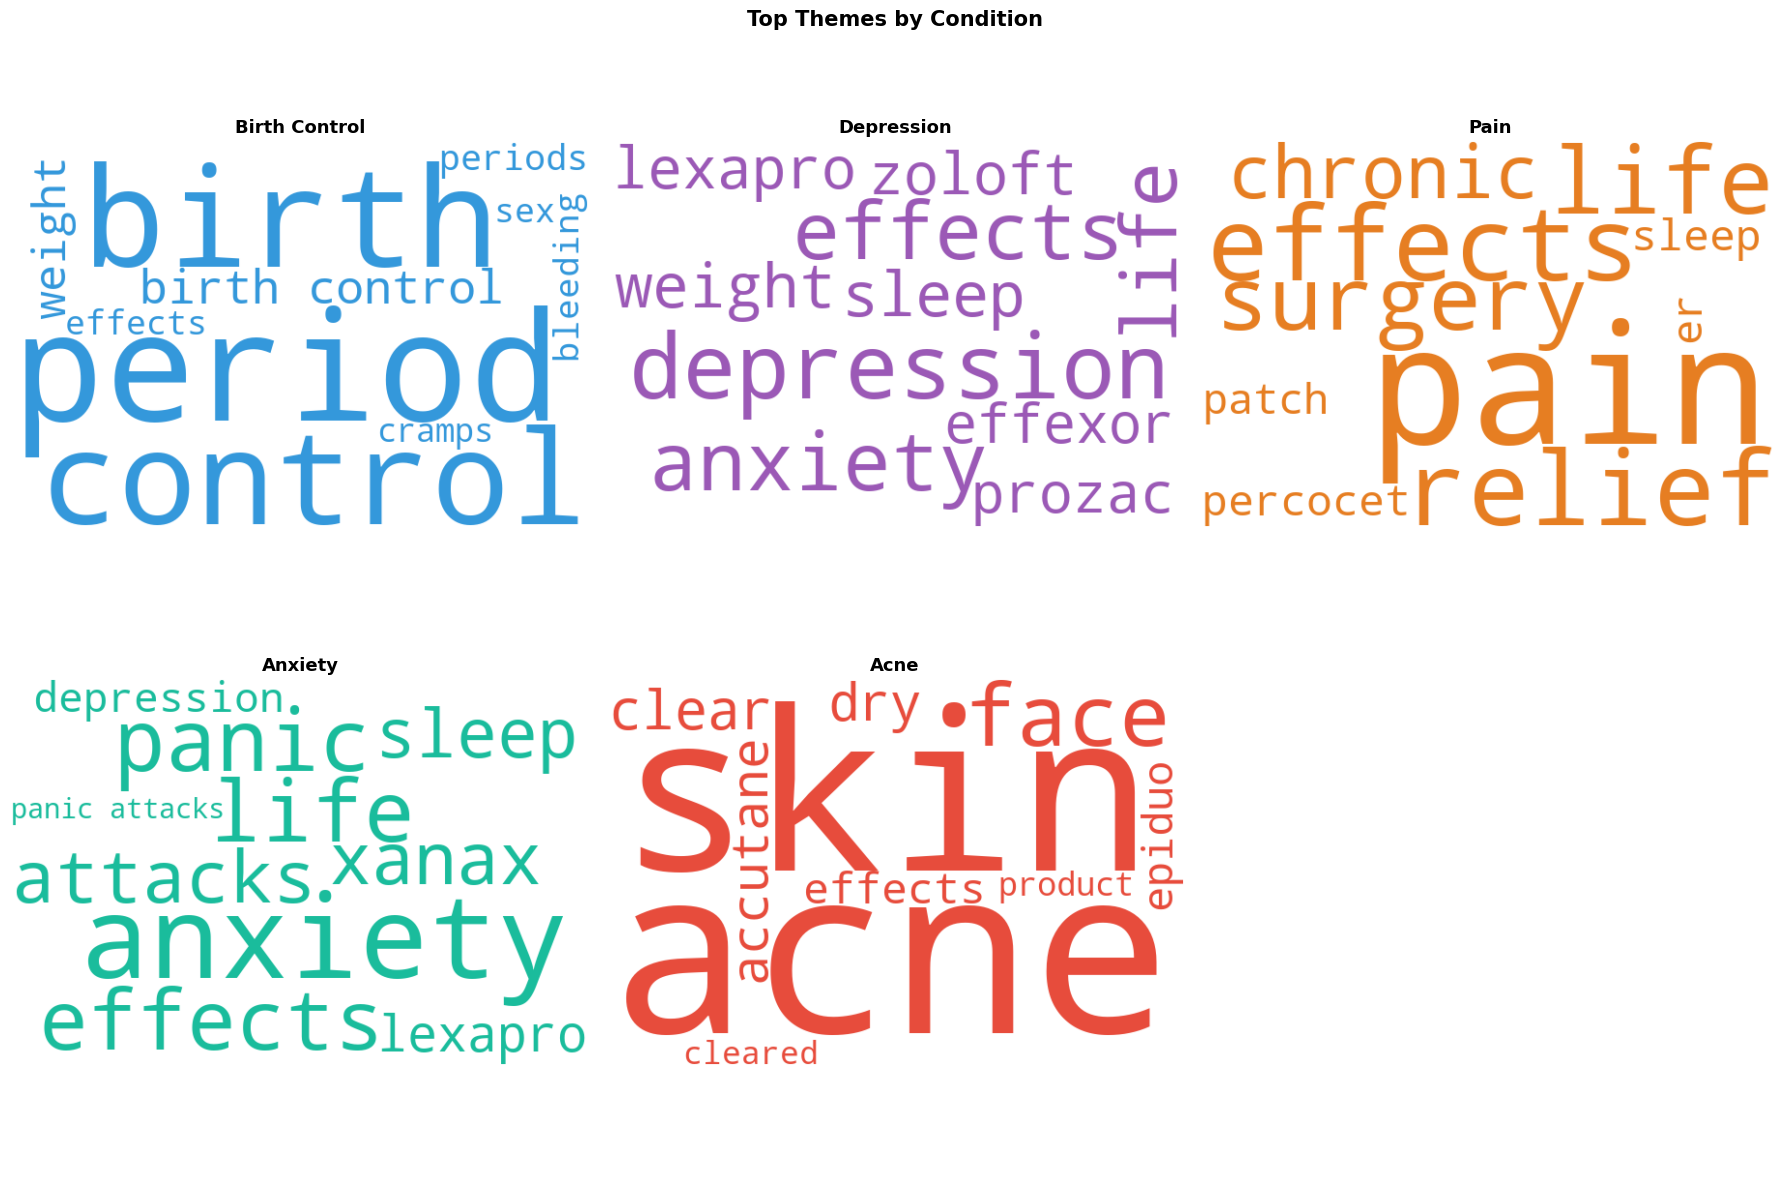

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']

for idx, (condition, themes) in enumerate(condition_themes.items()):
    word_freq = dict(zip(themes['term'], themes['score']))
    
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        color_func=lambda *args, color=colors[idx], **kwargs: color,
        max_words=10,
        prefer_horizontal=0.9
    ).generate_from_frequencies(word_freq)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"{condition}", 
                        fontsize=13, fontweight='bold')
    axes[idx].axis('off')

# Hide the empty 6th subplot
axes[5].axis('off')

plt.suptitle('Top Themes by Condition', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 4 — Key Findings Summary

Topic extraction using TF-IDF revealed distinctive and 
clinically meaningful theme profiles across sentiment 
categories and conditions.

**Cross-sentiment findings:**
- Pain and side effects are universal themes across all 
  sentiment categories confirming adverse drug reactions 
  are the central topic of patient drug reviews
- Positive reviews are characterised by life improvement 
  language — "life", "recommend", "normal"
- Negative reviews contain strong emotional language — 
  "horrible", "worst" — and treatment discontinuation 
  signals — "stopped", "stop"
- Neutral reviews describe symptoms factually without 
  emotional language

**Condition-specific findings:**
- Birth control themes align precisely with known 
  hormonal contraceptive side effect profiles
- Depression reviews feature brand name comparisons 
  reflecting the trial-and-error nature of 
  antidepressant selection
- Pain reviews reveal opioid therapy prominence 
  with Percocet and transdermal patch references
- Anxiety reviews capture specific disorder language 
  with panic attacks emerging as a key phrase
- Acne reviews are outcome-focused with retinoid 
  treatments and dryness side effects prominent

**Implications for Phase 5:**
The condition-specific themes will be used in the 
Streamlit app to display the most relevant topics 
when a user searches by drug or condition, providing 
context beyond simple sentiment scores.